# Import modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pyproj
import sys
sys.path.insert(0, '../')
from pysheds.grid import Grid
import seaborn as sns
import rasterio
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
sns.set_palette('husl', 8)

# Create empty grid instance

In [3]:
grid = Grid()

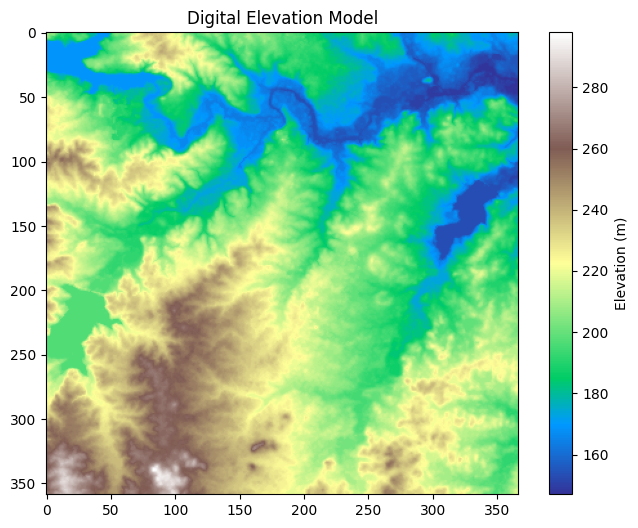

In [42]:
FILE = '../data/dem.tif'
grid = Grid.from_raster(FILE)
dem = grid.read_raster(FILE).astype(float)

# Mask the extreme negative nodata values
dem[dem < -100] = np.nan 

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(dem, cmap='terrain', zorder=1)
plt.colorbar(im, label='Elevation (m)')
plt.title('Digital Elevation Model')
plt.show()

# Specify flow direction values

In [43]:
         #N    NE    E    SE    S    SW    W    NW
dirmap = (64,  128,  1,   2,    4,   8,    16,  32)

# Compute accumulation

In [44]:
# DEM Processing Steps
dem_filled = grid.fill_pits(dem)
dem_flooded = grid.fill_depressions(dem_filled)
dem_conditioned = grid.resolve_flats(dem_flooded)

# Generate Flow Direction
fdir = grid.flowdir(dem_conditioned, dirmap=dirmap)

In [45]:
acc = grid.accumulation(fdir=fdir, dirmap=dirmap)

# Delineate catchment

In [46]:
# Specify pour point (greatest accumulation)
y, x = np.unravel_index(np.argmax(acc), acc.shape)

# Delineate the catchment
catch = grid.catchment(fdir=fdir, x=x, y=y, dirmap=dirmap, 
                       recursionlimit=15000, xytype='index')

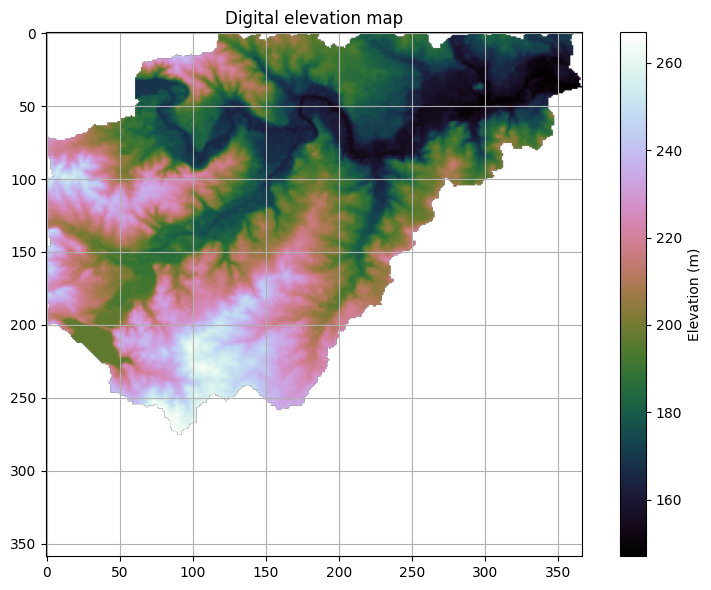

In [47]:
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(np.where(catch, dem, np.nan), cmap='cubehelix', zorder=1)
plt.colorbar(im, label='Elevation (m)')
plt.grid(zorder=0)
plt.title('Digital elevation map')
plt.tight_layout()

# Clip to catchment

In [54]:
# Update the grid's internal coordinate system to the catchment
grid.clip_to(catch)

# Get synchronized views for all layers
# This ensures all arrays have identical shapes (solving the broadcast error)
catch_view = grid.view(catch)
dem_view = grid.view(dem)
fdir_view = grid.view(fdir)

# Identify bounding box for title/info if needed
nz_y, nz_x = np.nonzero(catch_view)
print(f"Clipped grid shape: {catch_view.shape}")

Clipped grid shape: (275, 366)


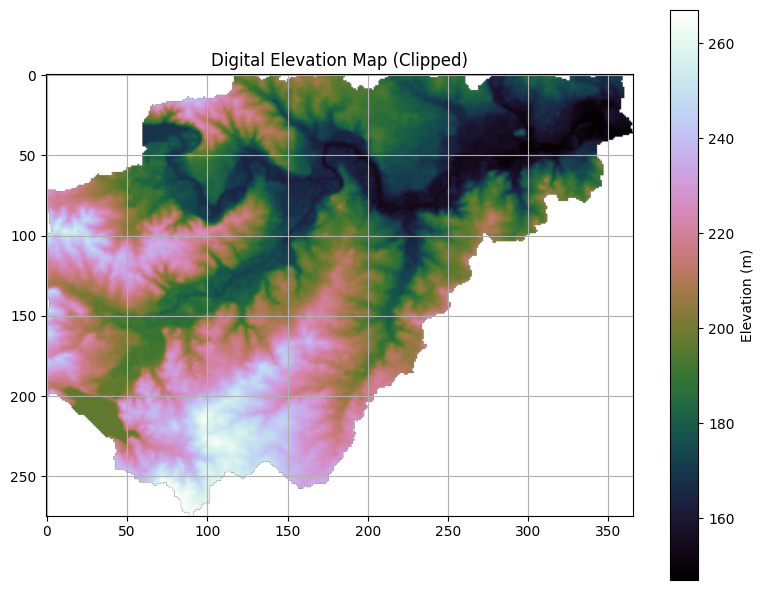

In [57]:
fig, ax = plt.subplots(figsize=(8,6))
# Using dem_view and catch_view ensures perfect alignment
im = ax.imshow(np.where(catch_view, dem_view, np.nan),
               cmap='cubehelix', zorder=1)
plt.colorbar(im, label='Elevation (m)')
plt.grid(zorder=0)
plt.title('Digital Elevation Map (Clipped)')
plt.tight_layout()

# Get flow accumulation in catchment

In [58]:
catch_acc = grid.accumulation(fdir=fdir_view, dirmap=dirmap)

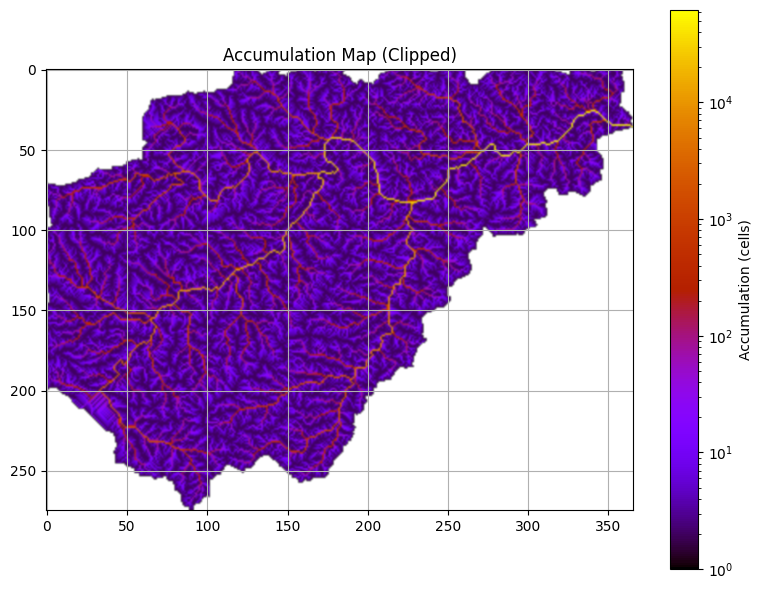

In [59]:
fig, ax = plt.subplots(figsize=(8,6))
# Now catch_view and (catch_acc + 1) are guaranteed to be the same shape
im = ax.imshow(np.where(catch_view, (catch_acc + 1), np.nan), 
               cmap='gnuplot', interpolation='bicubic',
               norm=colors.LogNorm(1, catch_acc.max()),
               zorder=1)
plt.colorbar(im, label='Accumulation (cells)')
plt.grid(zorder=0)
plt.title('Accumulation Map (Clipped)')
plt.tight_layout()

# Use different nodata value

In [60]:
# Create a copy and handle custom nodata
fdir_custom = fdir_view.copy()
# Map any existing NaNs or zeros to your custom value
fdir_custom[np.isnan(fdir_custom) | (fdir_custom == 0)] = -9999

catch_acc_custom = grid.accumulation(fdir=fdir_custom, dirmap=dirmap, nodata_in=-9999)

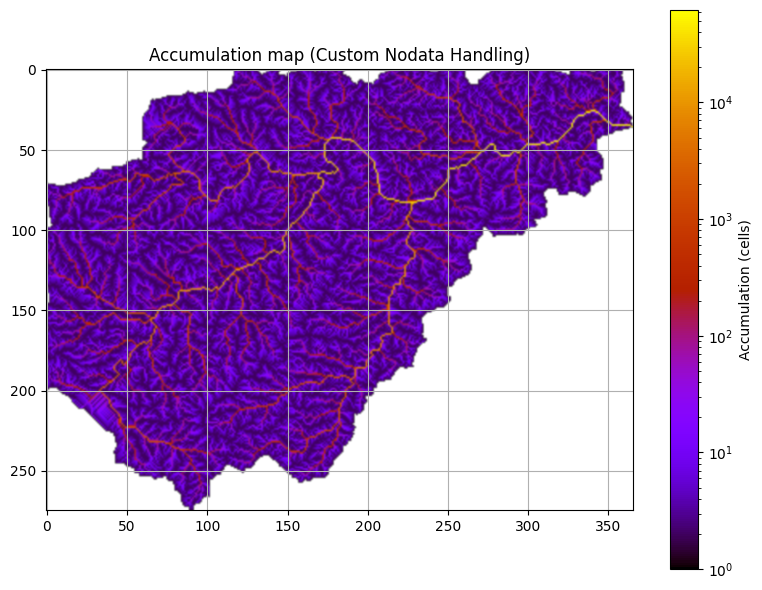

In [61]:
fig, ax = plt.subplots(figsize=(8,6))
# Use catch_view to mask the custom accumulation
im = ax.imshow(np.where(catch_view > 0, (catch_acc_custom + 1), np.nan), 
               cmap='gnuplot', interpolation='bicubic',
               norm=colors.LogNorm(1, catch_acc_custom.max()),
               zorder=1)
plt.colorbar(im, label='Accumulation (cells)')
plt.grid(zorder=0)
plt.title('Accumulation map (Custom Nodata Handling)')
plt.tight_layout()